In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("My_Food_Business_Sales_Inventory.csv")

In [34]:
df.head()

,Date,Day,Weekend,Public_Holiday,Weather,Time_Slot,Product,Total_Quantity_Prepared,Quantity_Sold,Selling_Price,Revenue,Estimated_Cost,Profit,Payment_Mode,Platform,Net_Profit/Loss
0,01-08-2024,Thursday,No,No,Rainy,8AM - 2PM,Pohe,10,6,20,120,166,-46,Cash,Offline,-86
1,01-08-2024,Thursday,No,No,Sunny,8AM - 2PM,Tarri Pohe,8,5,30,150,180,-30,Cash,Offline,-70
2,01-08-2024,Thursday,No,No,Sunny,8AM - 2PM,Misal Pav,4,2,40,80,109,-29,Cash,Offline,-69
3,01-08-2024,Thursday,No,No,Sunny,8AM - 2PM,Vada Pav,12,8,15,120,154,-34,Cash,Offline,-74
4,01-08-2024,Thursday,No,No,Rainy,8AM - 2PM,Bhaji Pav,5,3,15,45,67,-22,Cash,Offline,-62


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3212 entries, 0 to 3211
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Date                     3212 non-null   object
 1   Day                      3212 non-null   object
 2   Weekend                  3212 non-null   object
 3   Public_Holiday           3212 non-null   object
 4   Weather                  3212 non-null   object
 5   Time_Slot                3212 non-null   object
 6   Product                  3212 non-null   object
 7   Total_Quantity_Prepared  3212 non-null   int64 
 8   Quantity_Sold            3212 non-null   int64 
 9   Selling_Price            3212 non-null   int64 
 10  Revenue                  3212 non-null   int64 
 11  Estimated_Cost           3212 non-null   int64 
 12  Profit                   3212 non-null   int64 
 13  Payment_Mode             3212 non-null   object
 14  Platform                 3212 non-null  

In [10]:
df.shape

(3212, 16)

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
df.isnull().sum()

Date                       0
Day                        0
Weekend                    0
Public_Holiday             0
Weather                    0
Time_Slot                  0
Product                    0
Total_Quantity_Prepared    0
Quantity_Sold              0
Selling_Price              0
Revenue                    0
Estimated_Cost             0
Profit                     0
Payment_Mode               0
Platform                   0
Net_Profit/Loss            0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [12]:
## Created Month and year Columns.
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

In [14]:
##Created Wastage Column.
df['Wastage'] = df['Total_Quantity_Prepared'] - df['Quantity_Sold']

In [47]:
##Total Revenue.
print(df['Revenue'].sum())

427971


In [48]:
##Total Profit.
df['Profit'].sum()

25247

In [45]:
##Net Profit/Loss
print(df['Net_Profit/Loss'].sum())

-103233


In [49]:
## Total Quantity Sold.
df['Quantity_Sold'].sum()

19269

In [51]:
# Product-wise Revenue Analysis.
product_sales = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
product_sales

Product
Misal Pav      68960
Usal Pav       62510
Pohe           57220
Vada Misal     57200
Tarri Pohe     51840
Vada Pav       42825
Bhaji Plate    22220
Chai           17136
Pattice        16755
Bhaji Pav      16545
ButterMilk     14760
Name: Revenue, dtype: int64

In [20]:
##Product-wise NetProfit/Loss Analysis.
product_netProfit_Loss = df.groupby('Product')['Net_Profit/Loss'].sum().sort_values(ascending=False)
product_netProfit_Loss

Product
Pohe           -8044
Tarri Pohe     -8386
Vada Misal     -8411
Chai           -9074
Usal Pav       -9418
Misal Pav      -9571
ButterMilk     -9681
Bhaji Plate    -9867
Vada Pav       -9909
Bhaji Pav     -10402
Pattice       -10470
Name: Net_Profit/Loss, dtype: int64

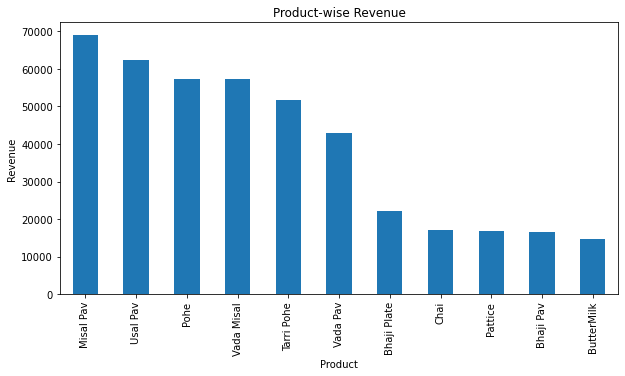

In [55]:
##Visualization.
product_sales.plot(kind='bar', figsize=(10,5))
plt.title('Product-wise Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

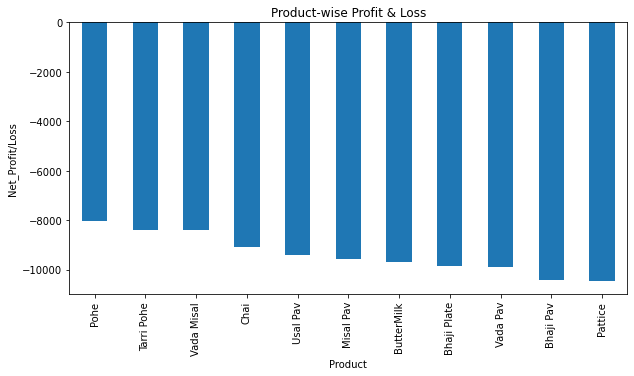

In [21]:
product_netProfit_Loss.plot(kind='bar', figsize=(10,5))
plt.title('Product-wise Profit & Loss')
plt.xlabel('Product')
plt.ylabel('Net_Profit/Loss')
plt.show()

In [58]:
##Weekend vs Weekday Analysis.
weekend_sales = df.groupby('Weekend')['Revenue'].sum()
weekend_sales

Weekend
No     196658
Yes    231313
Name: Revenue, dtype: int64

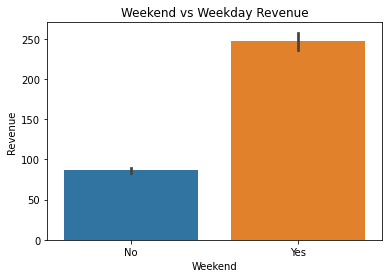

In [59]:
sns.barplot(x='Weekend', y='Revenue', data=df)
plt.title('Weekend vs Weekday Revenue')
plt.show()

###  Weekend sales were higher than weekday sales.

In [60]:
##Weather Analysis.
weather_sales = df.groupby('Weather')['Revenue'].sum()
weather_sales

Weather
Cloudy    111638
Rainy      46456
Sunny     269877
Name: Revenue, dtype: int64

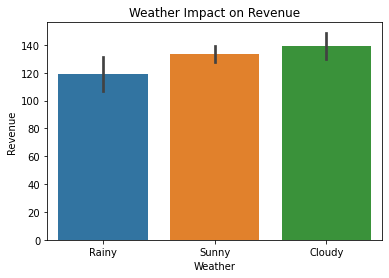

In [61]:
sns.barplot(x='Weather', y='Revenue', data=df)
plt.title('Weather Impact on Revenue')
plt.show()

### Rainy weather reduced customer sales.

In [64]:
##Monthly Net Profit Trend.
month_order = [
    'August','September','October','November',
    'December','January','February',
    'March','April','May'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)

monthly_profit = df.groupby('Month')['Net_Profit/Loss'].sum()

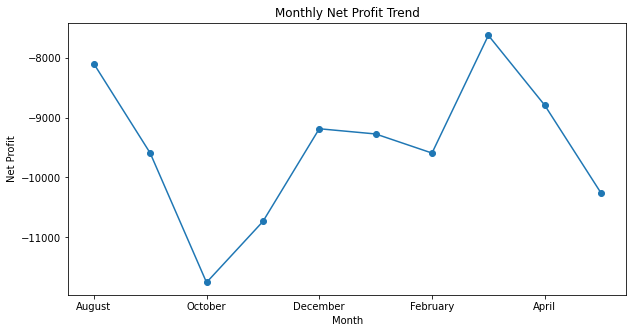

In [65]:
monthly_profit.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Monthly Net Profit Trend')
plt.ylabel('Net Profit')
plt.show()

### The business experienced unstable profits and overall losses across multiple months.


In [67]:
##Wastage Analysis.
wastage_analysis = df.groupby('Product')['Wastage'].sum().sort_values(ascending=False)
wastage_analysis

Product
Pohe           948
Chai           942
Vada Pav       920
Usal Pav       616
Misal Pav      615
Tarri Pohe     601
Bhaji Plate    446
Bhaji Pav      434
Pattice        430
Vada Misal     425
ButterMilk     410
Name: Wastage, dtype: int64

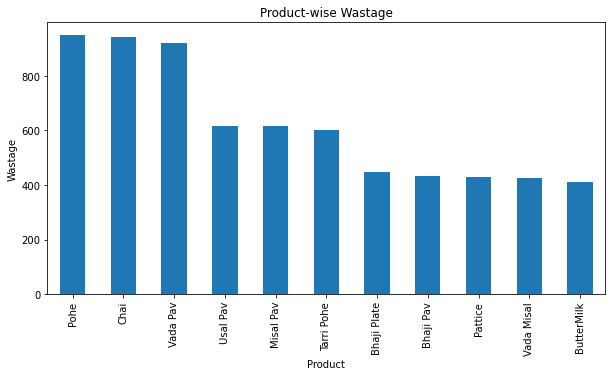

In [68]:
wastage_analysis.plot(kind='bar', figsize=(10,5))
plt.title('Product-wise Wastage')
plt.ylabel('Wastage')
plt.show()

### Over-preparation increased food wastage and contributed to business losses

In [23]:
##Platform Analysis.
platform_profit = df.groupby('Platform')['Net_Profit/Loss'].sum()
platform_profit

Platform
Offline   -76752
Swiggy    -16367
Zomato    -10114
Name: Net_Profit/Loss, dtype: int64

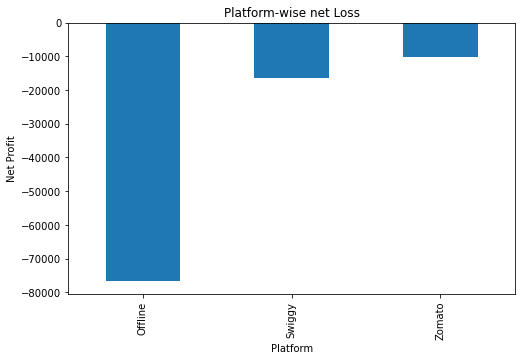

In [24]:
platform_profit.plot(kind='bar', figsize=(8,5))
plt.title('Platform-wise net Loss')
plt.xlabel('Platform')
plt.ylabel('Net Profit')
plt.show()

### The business faced losses on all platforms. Offline sales had the highest loss because daily operating expenses were high, while Swiggy and Zomato profits were reduced due to commission charges and fewer orders.

In [10]:
## Payment Mode Analysis.
payment_sales = df.groupby('Payment_Mode')['Revenue'].sum()
payment_sales

Payment_Mode
Cash           192834
Online          97526
OnlinePaytm    137611
Name: Revenue, dtype: int64

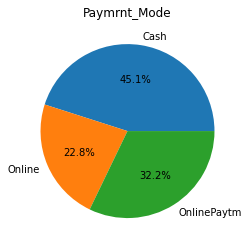

In [11]:
payment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Paymrnt_Mode')
plt.ylabel('')
plt.show()

### Cash remained the dominant payment method because the area is rural, but digital payments were also widely used.

## Overall Insight.
### These analysis revealed that the business was generating regular sales ,especially on weekends ,but low daily customer traffic, food wastage, rural area demand limitations, online platform commissions resulted in an overall net business loss.